# Summary plot: two-axion discovery reach

**Counting axions with IAXO** — B. Grinstein, C. Miró, P. Quílez (arXiv:2606.20826). Unbinned likelihood analysis.

Combines the quasi-degenerate and hierarchical discrimination limits with the CAST
exclusion, IAXO/IAXO+ projections, the QCD axion band, and haloscope bounds and
projections over the full $\sqrt{\Delta m_{21}^2}$ range.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import matplotlib.colors as mcolors
import os
%matplotlib inline

from iaxo_params import setup_plot_style

def lighten(color, alpha):
    """Lighten a color as alpha would, but opaque."""
    c = np.array(mcolors.to_rgb(color))
    return tuple(alpha * c + (1 - alpha) * np.ones(3))

def line_background(lw, col):
    return [pe.Stroke(linewidth=lw, foreground=col), pe.Normal()]

## Load bounds, projections and discovery limits

In [2]:
# Load CAST exclusion and IAXO / IAXO+ projections (common sqrt_dm2 grid)
data_CAST  = np.loadtxt('input_data/CAST_exclusion.dat')
data_IAXO  = np.loadtxt('input_data/IAXO_projection.dat')
data_IAXOp = np.loadtxt('input_data/IAXOplus_projection.dat')

x_all   = data_CAST[:, 0]   # sqrt(Delta_m21^2) [eV]  (CAST/IAXO/IAXO+ share this grid)
g_CAST  = data_CAST[:, 1]   # CAST exclusion   [GeV^-1]
g_IAXO  = data_IAXO[:, 1]   # IAXO projection  [GeV^-1]
g_IAXOp = data_IAXOp[:, 1]  # IAXO+ projection [GeV^-1]

print(f'Bounds: {len(x_all)} points, x = [{x_all[0]:.1e}, {x_all[-1]:.1e}] eV')

# Discovery limits
res_dir = 'results_data'

dq = np.loadtxt(os.path.join(res_dir, 'Quasi_Eres100eV.txt'))
x_quasi, g_quasi = dq[:, 0], dq[:, 1]

dq10 = np.loadtxt(os.path.join(res_dir, 'Quasi_Eres10eV.txt'))
x_quasi10, g_quasi10 = dq10[:, 0], dq10[:, 1]

dh = np.loadtxt(os.path.join(res_dir, 'Hier_profile_Eres100eV.txt'))
x_hier, g_hier = dh[:, 0], dh[:, 1]   # m2 = sqrt(Dm2) since m1 = 0

# Supernova quasi-degenerate (omega_res = 2 MeV)
d_sn = np.loadtxt('input_data/SN_Quasideg_IAXO_discovery_2MeV.dat')
x_sn, g_sn = d_sn[:, 0], d_sn[:, 1]

print(f'Quasi: {len(x_quasi)} pts | Hier: {len(x_hier)} pts | SN: {len(x_sn)} pts')

Bounds: 203 points, x = [1.0e-09, 1.0e+00] eV
Quasi: 100 pts | Hier: 100 pts | SN: 1000 pts


## Summary plot

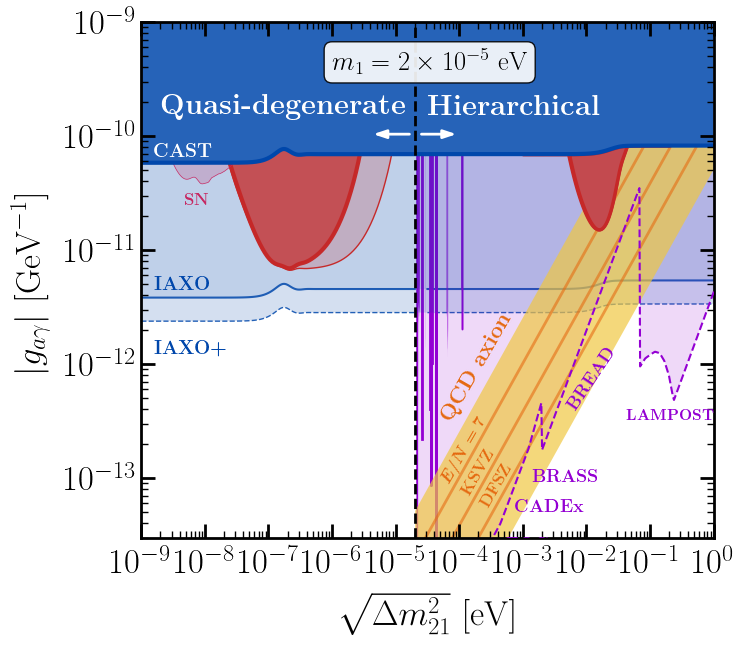

Saved to Overleaf: Summary.pdf/.png


In [27]:
from palettable.colorbrewer.sequential import YlOrRd_5
import matplotlib.cm as cm
from matplotlib.ticker import LogLocator

from PlotFuncs import AxionPhoton

# Quasi / hierarchical boundary
m1_value = 2e-5  # eV
m1_label = r'$m_1=2\times 10^{-5}\ \mathrm{eV}$'

colorsBounds = '#0047AB'
colorDisc = '#C62828'

setup_plot_style()
fig, ax = plt.subplots(figsize=(8, 7))

# CAST exclusion
ax.loglog(x_all, g_CAST, color=colorsBounds, lw=3, zorder=1)
ax.fill_between(x_all, g_CAST, 1e-6, facecolor=lighten(colorsBounds, 0.85), zorder=0.9, alpha=1)
ax.text(1.6e-9, 0.65e-10, r'{\bf CAST}', fontsize=14, color='w', zorder=1000)

# IAXO projection
filtquasi = x_all < m1_value
# extend the visible (quasi) segment up to the divider: the input grid has a
# gap (1e-6 -> 3e-5) and the projection is flat there, so plot a continuous line
xq      = np.append(x_all[filtquasi], m1_value)
gIAXOq  = np.append(g_IAXO[filtquasi],  g_IAXO[filtquasi][-1])
gIAXOpq = np.append(g_IAXOp[filtquasi], g_IAXOp[filtquasi][-1])
ax.fill_between(x_all, g_IAXO, g_CAST, facecolor=colorsBounds, zorder=0.15, alpha=0.25)
ax.loglog(xq, gIAXOq, color=colorsBounds, lw=1.5, ls='-', zorder=0.6, alpha=0.85)
ax.loglog(x_all[~filtquasi], g_IAXO[~filtquasi], color=colorsBounds, lw=1.5, ls='-', zorder=-1000, alpha=0.85)
ax.text(1.6e-9, 4.5e-12, r'{\bf IAXO}', fontsize=14, color=colorsBounds, zorder=1000)

# IAXO+ projection
ax.fill_between(x_all, g_IAXOp, g_IAXO, facecolor=colorsBounds, zorder=0.15, alpha=0.17)
ax.loglog(xq, gIAXOpq, color=colorsBounds, lw=1., ls='--', zorder=0.6, alpha=0.85)
ax.loglog(x_all[~filtquasi], g_IAXOp[~filtquasi], color=colorsBounds, lw=1., ls='--', zorder=-1000, alpha=0.85)
ax.text(1.6e-9, 1.2e-12, r'{\bf IAXO+}', fontsize=14, color=colorsBounds, zorder=1000)

# QCD axion band
x_QCD = np.logspace(np.log10(1e-9), np.log10(1.0), 1000)   # NOT x_all
m_min, m_max = 1e-9, 1.0
g_min, g_max = 3e-14, 1e-9
def g_ag(C_ag, m_a):
    return 2e-10 * C_ag * m_a
g_KSVZ  = g_ag(1.92, x_QCD)
g_DFSZ  = g_ag(0.75, x_QCD)
g_upper = g_ag(44/3 - 1.92, x_QCD)
g_lower = g_ag(1.92 - 5/3, x_QCD)
g_lim   = g_ag(7 - 1.92, x_QCD)
g_cut = 9e-11                        # extend QCD band up to ~weakest CAST
colQCD = "#F0C74086"
col_line = cm.YlOrBr(0.65)
mask_QCD_region = x_QCD >= m1_value
mask_KSVZ = (g_KSVZ <= g_cut) & mask_QCD_region
mask_DFSZ = (g_DFSZ <= g_cut) & mask_QCD_region
mask_lim  = (g_lim  <= g_cut) & mask_QCD_region
ax.plot(x_QCD[mask_KSVZ], g_KSVZ[mask_KSVZ], lw=2, color=col_line, alpha=0.58, zorder=0.82)
ax.plot(x_QCD[mask_DFSZ], g_DFSZ[mask_DFSZ], lw=2, color=col_line, alpha=0.58, zorder=0.82)
ax.plot(x_QCD[mask_lim],  g_lim[mask_lim],   lw=2, color=col_line, alpha=0.58, zorder=0.82)
mask_band = (g_lower <= g_cut) & mask_QCD_region
g_upper_eff = np.minimum(g_upper, g_cut)
ax.fill_between(x_QCD, g_lower, g_upper_eff, where=mask_band, facecolor=colQCD, alpha=0.69, zorder=0.8)
ax.text(4.7e-5, 3.2e-13, r'{\bf QCD\ axion}', fontsize=16, color=col_line, zorder=0.82, rotation=60)
ax.text(1e-4, 7e-14, r'{\bf KSVZ}', fontsize=12, color=col_line, zorder=0.82, rotation=60)
ax.text(2e-4, 5.5e-14, r'{\bf DFSZ}', fontsize=12, color=col_line, zorder=0.82, rotation=60)
ax.text(4.6e-5, 9.1e-14, r'{\boldmath$E/N = 7$}', fontsize=12, color=col_line, zorder=0.82, rotation=60)


# Discovery fills: interpolate CAST onto discovery grids
g_CAST_at_quasi = np.interp(x_quasi, x_all, g_CAST)
g_CAST_at_sn    = np.interp(x_sn, x_all, g_CAST)
g_CAST_at_hier  = np.interp(x_hier, x_all, g_CAST)

ax.fill_between(x_quasi, g_quasi, g_CAST_at_quasi, facecolor=colorDisc, alpha=0.7, zorder=0.38)
ax.fill_between(x_quasi10, g_quasi10, g_CAST_at_quasi, facecolor=colorDisc, alpha=0.2, zorder=0.38)
ax.fill_between(x_sn, g_sn, g_CAST_at_sn, facecolor='#c62862', alpha=0.2, zorder=0.38)
ax.fill_between(x_hier, g_hier, g_CAST_at_hier, facecolor='white', alpha=1, zorder=0.38)
ax.fill_between(x_hier, g_hier, g_CAST_at_hier, facecolor='#C34A4F',ec=colorDisc,lw=2.5, alpha=1, zorder=0.83)

# Discovery curves
ax.loglog(x_quasi, g_quasi, color=colorDisc, lw=3,
          label=r'Quasi-degenerate ($\omega_{\rm res}=100\ \mathrm{eV}$)', zorder=0.8, alpha=0.99)
ax.loglog(x_quasi10, g_quasi10, color=colorDisc, lw=1, ls='-',
          label=r'Quasi-degenerate ($\omega_{\rm res}=10\ \mathrm{eV}$)', zorder=0.8, alpha=0.99)
ax.loglog(x_hier, g_hier, color=colorDisc, lw=3,
          label=r'Hierarchical ($\omega_{\rm res}=100\ \mathrm{eV}$)', zorder=0.8, alpha=0.99)
ax.loglog(x_sn, g_sn, color='#c62862', lw=0.5, ls='-',
          label=r'SN quasi-deg ($\omega_{\rm res}=2\ \mathrm{MeV}$)', zorder=0.8, alpha=0.99)
ax.text(3*1.6e-9, 2.5e-11, r'{\bf SN}', fontsize=12, color='#c62862', zorder=1000)

# Divide: quasi-degenerate vs hierarchical
ax.vlines(m1_value, g_min, g_max, ls='--', lw=2, color='k')
ax.text(0.1/2 * m1_value, 3.8e-10, m1_label,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9), fontsize=19)
lowerfactor = 1.3
ax.text(1.6 * m1_value, 2e-10/lowerfactor, r'{\bf Hierarchical}', fontsize=21, color='w')
ax.text(0.04e-7 / 10**0.3, 2e-10/lowerfactor, r'{\bf Quasi-degenerate}', fontsize=21, color='w')
ax.annotate('', xy=(m1_value/5, 1.35e-10/lowerfactor), xytext=(m1_value/1.1, 1.35e-10/lowerfactor),
            arrowprops=dict(arrowstyle='-|>,head_length=0.3,head_width=0.1', color='w', lw=2))
ax.annotate('', xy=(m1_value*5, 1.35e-10/lowerfactor), xytext=(1.15*m1_value, 1.35e-10/lowerfactor),
            arrowprops=dict(arrowstyle='-|>,head_length=0.3,head_width=0.1', color='w', lw=2))

# Haloscope projections (combined line)
col = 'darkviolet'
dat = np.loadtxt("limit_data/AxionPhoton/Projections/HaloscopeProjections_Combined.txt")
filt = dat[:, 0] > m1_value
plt.fill_between(dat[filt, 0], dat[filt, 1], y2=1, lw=0, color=col, alpha=0.15, zorder=-10)
plt.plot(dat[filt, 0], dat[filt, 1], '--', color=col, lw=1.5, zorder=10)

ax.set_xlabel(r"$\sqrt{\Delta m_{21}^2}\ [\mathrm{eV}]$", labelpad=10,
              path_effects=line_background(3.5, 'w'))
ax.set_ylabel(r"$|g_{a\gamma}|\ [\mathrm{GeV}^{-1}]$", labelpad=10)

plt.text(7.5e-4, 5.0e-14, r'{\bf CADEx}', color=col, fontsize=13, rotation=0, clip_on=True)
plt.text(5.5e-4, 2.3e-14, r'{\bf EQC}', color=col, fontsize=13, rotation=0, clip_on=True)
plt.text(1.4e-3, 9.3e-14, r'{\bf BRASS}', color=col, fontsize=13, rotation=0, clip_on=True)
plt.text(4.6e-3, 3.9e-13, r'{\bf BREAD}', color=col, fontsize=13, rotation=56, clip_on=True)
plt.text(4.2e-2, 0.4e-12, r'{\bf LAMPOST}', rotation=0, fontsize=11, color=col,
         ha='left', va='top', clip_on=True)

ax.set_xlim([m_min, m_max])
ax.set_ylim([g_min, g_max])

ax.xaxis.set_major_locator(LogLocator(base=10, numticks=20))
ax.xaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10), numticks=100))
ax.tick_params(axis='x', which='major', pad=8)
ax.tick_params(axis='x', which='minor', pad=8)

# Haloscope bounds (masses > m1_value)
AxionPhoton.ADMX(ax, text_on=False, col=col, zorder=-20)
AxionPhoton.HAYSTAC(ax, text_on=False, col=col, projection=False)
AxionPhoton.CAPP(ax, text_on=False, col=col)
AxionPhoton.QUAX(ax, text_on=False, col=col, projection=False)
AxionPhoton.ORGAN(ax, text_on=False, col=col, lw=0, projection=False)
AxionPhoton.RADES(ax, text_on=False, col=col)
AxionPhoton.GrAHal(ax, text_on=False, col=col)
AxionPhoton.ADMX_SLIC(ax, text_on=False, col=col)
AxionPhoton.ALPS(ax, text_on=False, col=col, projection=False)
AxionPhoton.CASTCAPP(ax, text_on=False)
AxionPhoton.RBF_UF(ax, text_on=False, col=col)

# White cover for the quasi-degenerate region (haloscopes only apply to m > m1_value)
ax.axvspan(m_min, m1_value, color='w', zorder=0.1)

plt.tight_layout()

os.makedirs('plots', exist_ok=True)
fig.savefig('plots/Summary.pdf', bbox_inches='tight')
fig.savefig('plots/Summary.png', bbox_inches='tight')
plt.show()

# Optional: save directly into the Overleaf paper folder with the paper's figure names
save_overleaf = True
overleaf_dir = ('/home/pabloql/Cloud/Dropbox/Aplicaciones/Overleaf/'
                'Counting axions with helioscopes/plots')
if save_overleaf and os.path.isdir(overleaf_dir):
    for ext in ('pdf', 'png'):
        fig.savefig(os.path.join(overleaf_dir, 'Summary.' + ext),
                    bbox_inches='tight')
    print('Saved to Overleaf: Summary.pdf/.png')